# SpaceX Falcon 9 — EDA with Data Visualization

Six charts required by the capstone: Flight Number vs. Launch Site, Payload vs.
Launch Site, Success Rate vs. Orbit Type, Flight Number vs. Orbit Type, Payload
vs. Orbit Type, and the yearly launch-success trend.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

BASE = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork"
df = pd.read_csv(f"{BASE}/datasets/dataset_part_2.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

BLUE, GREEN, RED, DARKBLUE = "#0F62FE", "#24A148", "#DA1E28", "#002D9C"
colors = df['Class'].map({1: GREEN, 0: RED})
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013


## Flight Number vs. Launch Site

Later flight numbers cluster toward successful landings (green) as SpaceX's recovery process matured.

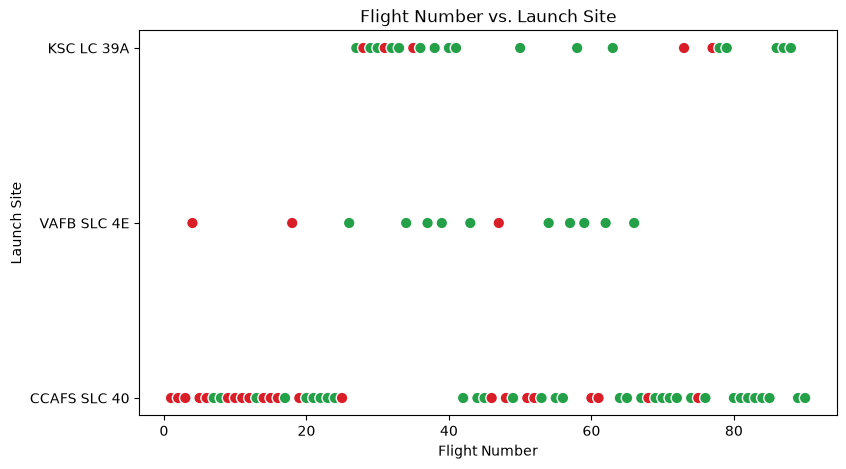

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['FlightNumber'], df['LaunchSite'], c=colors, s=70, edgecolor='white')
ax.set_xlabel('Flight Number'); ax.set_ylabel('Launch Site')
ax.set_title('Flight Number vs. Launch Site')
plt.show()

## Payload vs. Launch Site

Heavier payloads are concentrated at KSC LC-39A and VAFB SLC-4E.

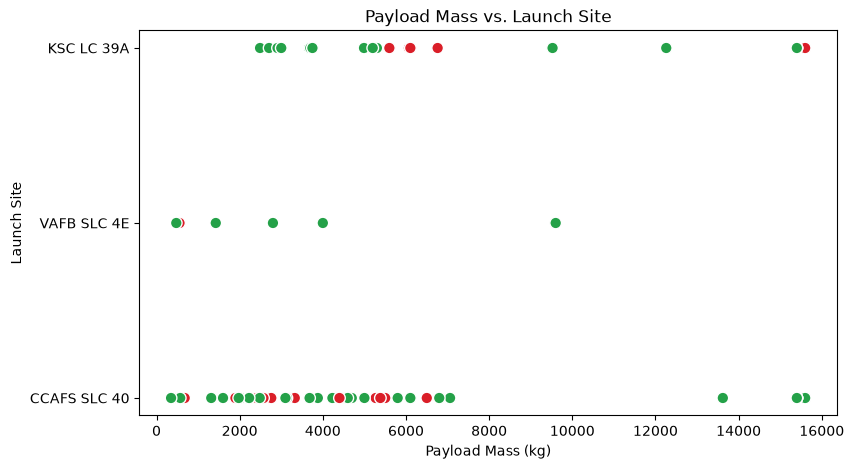

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['PayloadMass'], df['LaunchSite'], c=colors, s=70, edgecolor='white')
ax.set_xlabel('Payload Mass (kg)'); ax.set_ylabel('Launch Site')
ax.set_title('Payload Mass vs. Launch Site')
plt.show()

## Success Rate vs. Orbit Type

ES-L1, GEO, HEO and SSO orbits show a 100% landing success rate in this dataset (small sample sizes); GTO is the hardest orbit for a successful recovery.

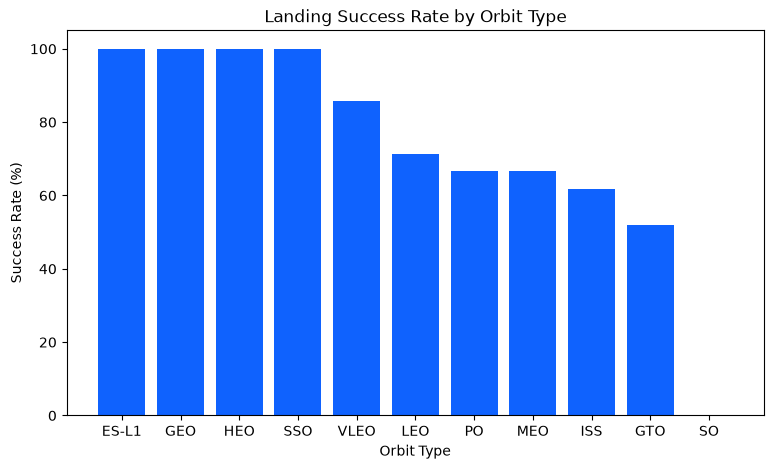

Orbit
ES-L1    1.000000
GEO      1.000000
HEO      1.000000
SSO      1.000000
VLEO     0.857143
LEO      0.714286
PO       0.666667
MEO      0.666667
ISS      0.619048
GTO      0.518519
SO       0.000000
Name: Class, dtype: float64

In [4]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(orbit_success.index, orbit_success.values * 100, color=BLUE)
ax.set_ylabel('Success Rate (%)'); ax.set_xlabel('Orbit Type')
ax.set_title('Landing Success Rate by Orbit Type')
plt.show()
orbit_success

## Flight Number vs. Orbit Type

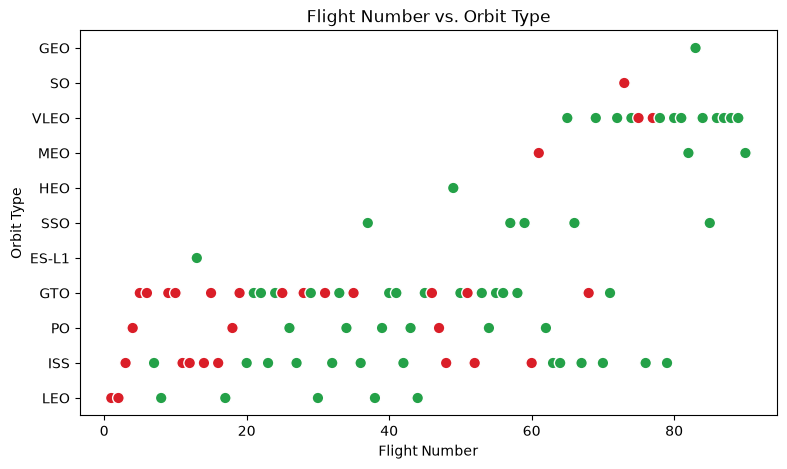

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['FlightNumber'], df['Orbit'], c=colors, s=70, edgecolor='white')
ax.set_xlabel('Flight Number'); ax.set_ylabel('Orbit Type')
ax.set_title('Flight Number vs. Orbit Type')
plt.show()

## Payload vs. Orbit Type

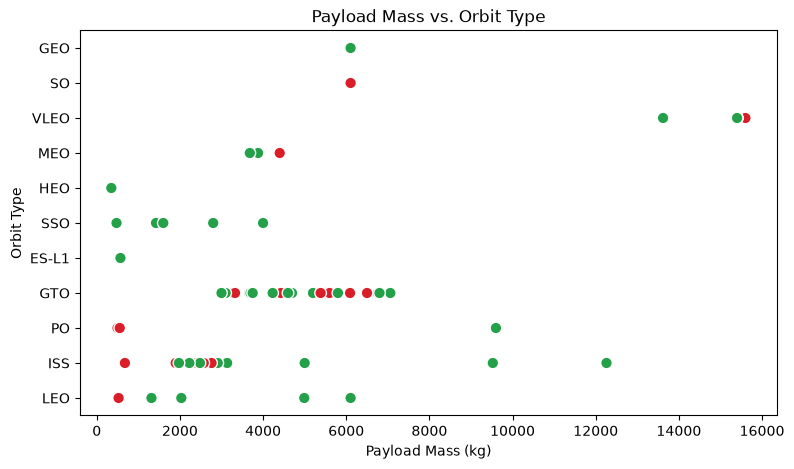

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['PayloadMass'], df['Orbit'], c=colors, s=70, edgecolor='white')
ax.set_xlabel('Payload Mass (kg)'); ax.set_ylabel('Orbit Type')
ax.set_title('Payload Mass vs. Orbit Type')
plt.show()

## Launch Success Yearly Trend

The average landing success rate climbs steadily from 0% in 2010–2013 to ~84–90% by 2019–2020.

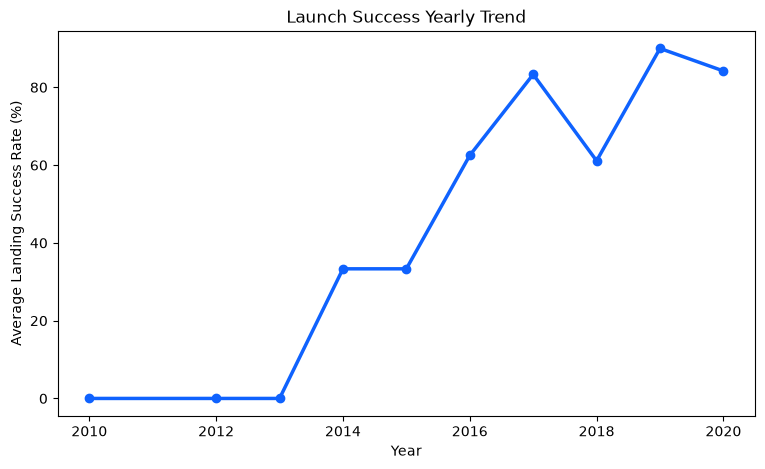

Year
2010    0.000000
2012    0.000000
2013    0.000000
2014    0.333333
2015    0.333333
2016    0.625000
2017    0.833333
2018    0.611111
2019    0.900000
2020    0.842105
Name: Class, dtype: float64

In [7]:
yearly = df.groupby('Year')['Class'].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly.index, yearly.values * 100, marker='o', color=BLUE, linewidth=2.5)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xlabel('Year'); ax.set_ylabel('Average Landing Success Rate (%)')
ax.set_title('Launch Success Yearly Trend')
plt.show()
yearly

## Feature engineering for modeling

One-hot encode the categorical columns so the table can feed directly into classification models (this mirrors `dataset_part_3.csv`).

In [8]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
               'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block',
               'ReusedCount', 'Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot = features_one_hot.astype('float64')
features_one_hot.to_csv('dataset_part_3.csv', index=False)
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
